### Линейная регрессия


Суть метода заключается в построении линейной функции, которая наилучшим образом описывает данные, для этого минимизируется сумма квадратов ошибок между предсказанными и фактическими значениями.

## Используемые библиотеки

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import seaborn as sns

## Используемый датасет

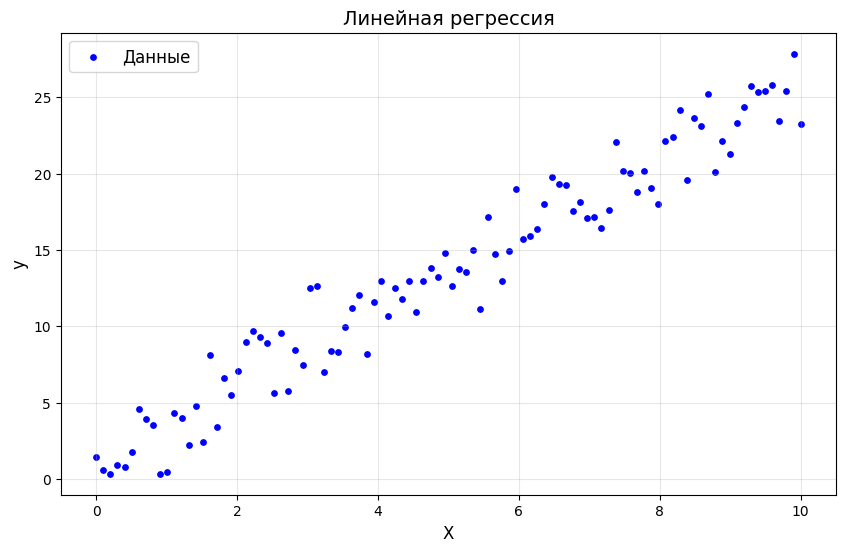

In [47]:
np.random.seed(19)
n_samples = 100
X = np.linspace(0, 10, n_samples).reshape(-1, 1)

true_b = 2.5
true_a = 1.0

noise = np.random.randn(n_samples, 1) * 2
y = true_a + true_b * X + noise

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Данные', s=15)

plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Линейная регрессия', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

## Обработка датасета

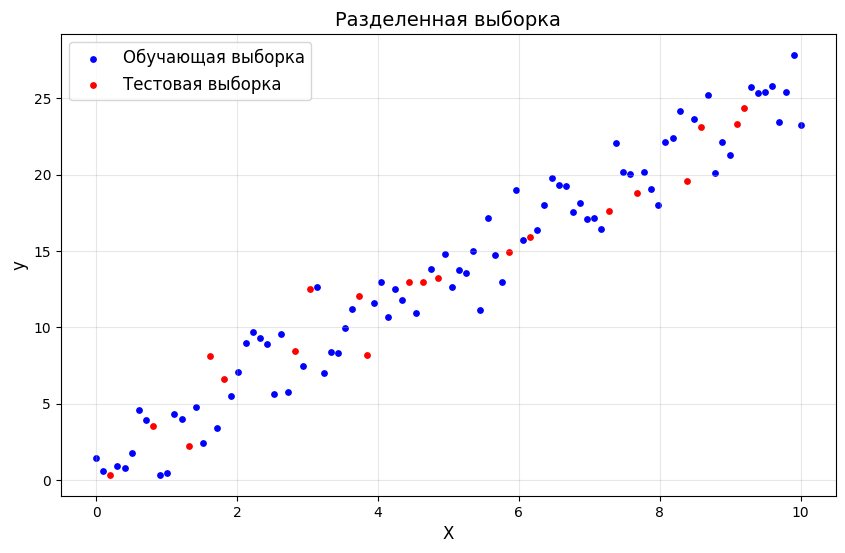

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=19
)
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='Обучающая выборка', s=15)
plt.scatter(X_test, y_test, color='red', label='Тестовая выборка', s=15)

plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Разделенная выборка', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

## Тепловая карта

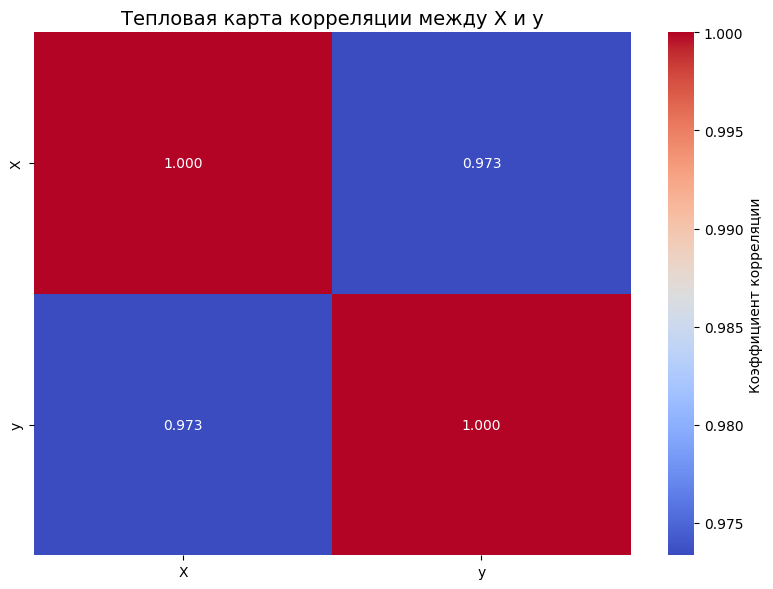

In [49]:
plt.figure(figsize=(8, 6))
data_for_corr = np.column_stack((X.flatten(), y.flatten()))
sns.heatmap(np.corrcoef(data_for_corr.T),
            annot=True,
            fmt='.3f',
            xticklabels=['X', 'y'],
            yticklabels=['X', 'y'],
            cmap='coolwarm',
            cbar_kws={'label': 'Коэффициент корреляции'})
plt.title('Тепловая карта корреляции между X и y', fontsize=14)
plt.tight_layout()
plt.show()


## Обучение модели

In [50]:
model = LinearRegression(fit_intercept=True, positive=False)
model.fit(X_train, y_train)

LinearRegression()

## Прогнозы модели

In [51]:
y_test_pred = model.predict(X_test)
print(y_test_pred)

[[22.55561485]
 [19.25902294]
 [ 5.05831934]
 [ 5.56548732]
 [ 1.50814344]
 [10.63716718]
 [23.82353482]
 [ 8.60849524]
 [22.04844687]
 [16.46959902]
 [ 3.02964739]
 [12.15867114]
 [24.07711881]
 [ 4.29756736]
 [10.38358319]
 [12.66583913]
 [ 8.10132725]
 [15.70884704]
 [13.17300711]
 [20.27335891]]


## Графики выходных результатов

Уравнение регрессии: y = 1.0010 + 2.5105 * x
Истинное уравнение: y = 1.0 + 2.5 * x


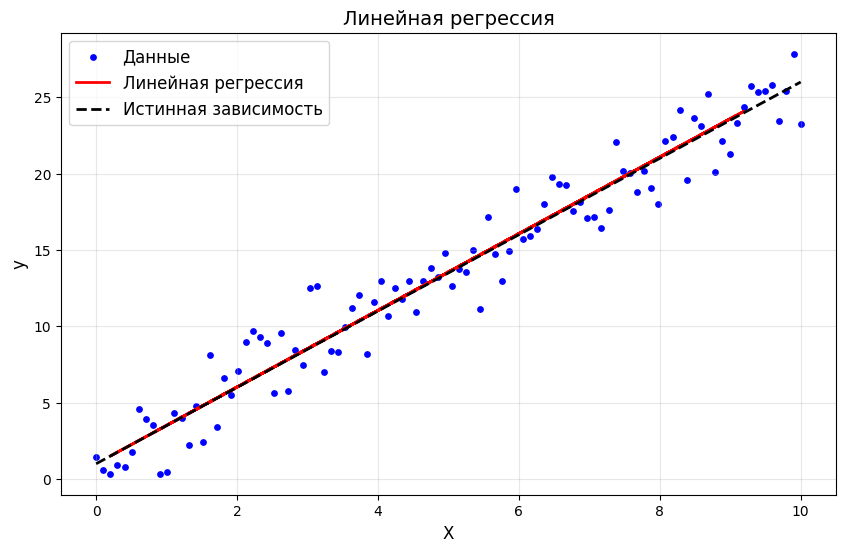

In [52]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Данные', s=15)
plt.plot(X_test, y_test_pred, color='red', linewidth=2, label='Линейная регрессия')
plt.plot(X, true_a + true_b * X, color='black', linestyle='--', linewidth=2, label='Истинная зависимость')

plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Линейная регрессия', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

print(f"Уравнение регрессии: y = {model.intercept_[0]:.4f} + {model.coef_[0][0]:.4f} * x")
print(f"Истинное уравнение: y = {true_a} + {true_b} * x")

plt.show()